# Random incenter vs Diffusion — fixed-horizon comparison, including parameter noise

This notebook compares **Random S + incenter estimation** with the new **Diffusion algorithm** on the same 12 MIN-expert scenario families as notebook 10. **Both run to T=8**, even after a good estimate appears. Eight families have no parameter noise; four have parameter noise. Observations are clean (Y=X), but parameter perturbations can change the expert's MIN decision.

All outputs, tables and plots are saved inline. One seed (0), 16 candidate queries and 32 independent hidden test queries keep this an exploratory, small-budget comparison, not a definitive ranking.

We track parameter recovery as angular error to theta* (direction, not exact magnitude), and decision quality as normalized test regret. The thresholds, set before running, are **angle <= 5 degrees**, **mean regret <= 0.01**, and both simultaneously. We also show exact-zero test-regret times.

- **First t:** earliest post-observation step satisfying the threshold.
- **Stable t through T:** earliest step satisfying it at EVERY remaining step through T. This is retrospective; a hit at T alone does not prove future stability.
- **Not reached:** not observed within the budget, not a successful stop at T.
- Invalid/collapsed-cone estimates are explicit failures and never count as threshold hits.

The algorithms share scenario definitions, candidate pools, theta*, test queries and parameter-noise RNG seeds. Their chosen queries and resulting responses differ. Evaluation uses clean decisions under the fixed theta*: the parameter-noise realization is not the recovery target. The algorithms cannot access truth or test answers.

Diffusion uses four retained parameters, three smoothing levels, 32 inner steps and four outer steps per level, with the first sample as its estimate. This is a smaller sampling budget than notebook 11 (64 inner / eight outer steps), selected to keep the 10-20 dimensional LP/MILP cases manageable. No test-based hyperparameter tuning is performed. Since query selection AND estimation differ, this compares complete algorithms; it does not isolate the benefit of active query selection alone.


In [1]:
from pathlib import Path
from dataclasses import asdict
import sys
import time
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "invoptlab").exists())
sys.path.insert(0, str(root / "src"))
from invoptlab.active import (
    ActiveResearchConfig, UniformRandomIncenterAlgorithm,
    NestedLangevinConfig, NestedLangevinActiveAlgorithm,
    build_active_research_scenarios, run_active_research_benchmark, save_active_research,
)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)

protocol = ActiveResearchConfig(
    seeds=(0,), horizon=8, candidate_count=16,
    validation_query_count=16, test_query_count=32,
    validation_seed=40001, test_seed=90001,
    fixed_horizon=True,
    learning_regret_threshold=0.01, learning_angular_threshold_degrees=5.0,
)
diffusion_config = NestedLangevinConfig(
    sampler="projected_langevin", point_estimate="first", query_tie_breaking="first",  # Historical v2 run
    beta=20.0, parameter_domain="box", bound=1.0,
    tau_schedule=(0.5, 0.1, 0.02),
    inner_step_sizes=(0.02, 0.005, 0.001),
    outer_step_sizes=(0.1, 0.02, 0.004),
    theta_samples=4, inner_steps=32, inner_burn_in=16, inner_thinning=4,
    outer_steps=4, workers=1, record_chain_trace=False,
    initialization_std=1.0, warm_start=True,
    warm_start_renoise_std=0.0, warm_start_inner=False,
)
algorithms = {
    "Random + incenter": lambda: UniformRandomIncenterAlgorithm(alternative_budget=64),
    "Diffusion": lambda: NestedLangevinActiveAlgorithm(diffusion_config),
}
artifact_dir = root / "outputs" / "active" / "12_diffusion_comparison"
display(pd.DataFrame({"protocol input": list(asdict(protocol)), "value": [str(v) for v in asdict(protocol).values()]}))
display(pd.DataFrame({"diffusion input": list(asdict(diffusion_config)), "value": [str(v) for v in asdict(diffusion_config).values()]}))


,protocol input,value
0,seeds,"(0,)"
1,horizon,8
2,candidate_count,16
3,validation_query_count,16
4,test_query_count,32
5,validation_seed,40001
6,test_seed,90001
7,consecutive_validation_successes,3
8,zero_regret_tolerance,1e-08
9,learning_regret_threshold,0.01


,diffusion input,value
0,beta,20.0
1,parameter_domain,box
2,bound,1.0
3,tau_schedule,"(0.5, 0.1, 0.02)"
4,inner_step_sizes,"(0.02, 0.005, 0.001)"
5,outer_step_sizes,"(0.1, 0.02, 0.004)"
6,inner_steps,32
7,inner_burn_in,16
8,inner_thinning,4
9,outer_steps,4


In [2]:
scenarios = build_active_research_scenarios(protocol)
scenario_table = pd.DataFrame([{
    "family": s.metadata["research_family"],
    "dimension": s.dimension,
    "decision_space": s.decision_space.kind.value,
    "query_geometry": s.query_space.kind.value,
    "parameter_noise": s.parameter_noise.kind.value,
    "target_decision_change_fraction": s.parameter_noise.target_decision_change_rate,
    "observation_noise": s.observation_noise.kind.value,
} for s in scenarios])
display(scenario_table)
assert len(scenarios) == 12
assert sum(s.parameter_noise.kind.value != "none" for s in scenarios) == 4


,family,dimension,decision_space,query_geometry,parameter_noise,target_decision_change_fraction,observation_noise
0,geometry-cardinality-3d,3,fixed_cardinality,balanced,none,NaN,clean
1,cardinality-balanced-d20,20,fixed_cardinality,balanced,none,NaN,clean
2,cardinality-small-margin-d20,20,fixed_cardinality,sharp_boundary,none,NaN,clean
3,knapsack-d20,20,structured,balanced,none,NaN,clean
4,dag-path-d18,18,structured,balanced,none,NaN,clean
5,continuous-simplex-d10,10,continuous_polytope,balanced,none,NaN,clean
6,cardinality-sparse-queries-d20,20,fixed_cardinality,sparse,none,NaN,clean
7,cardinality-rare-informative-d20,20,fixed_cardinality,rare_informative,none,NaN,clean
8,cardinality-parameter-noise-mild-d20,20,fixed_cardinality,balanced,isotropic,0.05,clean
9,cardinality-parameter-noise-moderate-d20,20,fixed_cardinality,balanced,isotropic,0.15,clean


## Execute both algorithms through the full horizon

Each completed run is checkpointed as a JSON artifact as well as retained in the notebook's tables. Those JSON files are optional; the notebook contains the plots and conclusions. No early stopping or hidden evaluation feedback is used to alter sampling.


In [3]:
def checkpoint(run):
    run.save_json(artifact_dir / f"{run.scenario.name}--{run.algorithm_name.replace(' ', '_')}.json")
    ev = run.evaluation
    print(f"Completed {run.scenario.metadata['research_family']} / {run.algorithm_name}: "
          f"T={len(run.records)}, status={ev['final_status']}, "
          f"regret={ev['final_normalized_regret']}, angle={ev['final_angular_error_degrees']}", flush=True)

started = time.perf_counter()
benchmark, aggregate = run_active_research_benchmark(
    algorithms, protocol, fail_fast=False,
    progress=lambda i, scenario, name: print(f"[{i}/24] {scenario.name} | {name}", flush=True),
    run_completed=checkpoint,
)
wall_seconds = time.perf_counter() - started
benchmark.metadata["diffusion_config"] = asdict(diffusion_config)
benchmark.metadata["comparison_wall_seconds"] = wall_seconds
benchmark.metadata["source_sha256"] = {
    str(path.relative_to(root)): hashlib.sha256(path.read_bytes()).hexdigest()
    for path in [
        root / "src/invoptlab/active/langevin.py",
        root / "src/invoptlab/active/research.py",
        root / "src/invoptlab/active/evaluation.py",
    ]
}
save_active_research(benchmark, aggregate, artifact_dir)
print(f"Comparison complete: {len(benchmark.runs)} runs; {wall_seconds:.1f} seconds wall time.")
print("Execution errors:", [(r.scenario.name, r.algorithm_name, r.error) for r in benchmark.failed_runs])


[1/24] research-geometry-cardinality-3d-s0 | Random + incenter


[2/24] research-geometry-cardinality-3d-s0 | Diffusion


Completed geometry-cardinality-3d / Random + incenter: T=8, status=valid, regret=0.0, angle=5.89681527675956


Completed geometry-cardinality-3d / Diffusion: T=8, status=valid, regret=0.0008884165227414885, angle=3.225757834969096


[3/24] research-cardinality-balanced-d20-s0 | Random + incenter


...

[23/24] research-knapsack-parameter-noise-moderate-d20-s0 | Random + incenter


[24/24] research-knapsack-parameter-noise-moderate-d20-s0 | Diffusion


Completed knapsack-parameter-noise-moderate-d20 / Random + incenter: T=8, status=valid, regret=0.009068692855807785, angle=30.797992679044402


Completed knapsack-parameter-noise-moderate-d20 / Diffusion: T=8, status=valid, regret=0.012329847791264151, angle=24.7353855852193


Comparison complete: 24 runs; 171.1 seconds wall time.
Execution errors: []


## Final results, failures, and time to reach the thresholds

Times are query counts, not seconds. Regret values are fractions (0.01 = 1%). An invalid final estimate has undefined angle/regret, even if an earlier estimate was good. “First” and “stable” times are calculated from the full trajectory, so an eventual failure does not erase a genuine early hit but does break stability.

The angle and regret tables are both needed: low regret does not prove theta recovery. Every numerical ranking below is descriptive for this seed and budget only.


In [4]:
rows, trajectory_rows = [], []
for run in benchmark.runs:
    e = run.evaluation or {}
    family = run.scenario.metadata["research_family"]
    rows.append({
        "family": family, "algorithm": run.algorithm_name,
        "noise": run.scenario.parameter_noise.kind.value != "none",
        "steps": len(run.records), "status": e.get("final_status", "execution_error"),
        "final_regret": e.get("final_normalized_regret"),
        "final_angle_deg": e.get("final_angular_error_degrees"),
        "zero_regret_fraction": e.get("final_zero_regret_rate"),
        "first_angle_t": e.get("first_angular_threshold_step"),
        "stable_angle_t": e.get("stable_angular_threshold_step"),
        "first_regret_t": e.get("first_threshold_step"),
        "stable_regret_t": e.get("stable_threshold_step"),
        "first_both_t": e.get("first_joint_threshold_step"),
        "stable_both_t": e.get("stable_joint_threshold_step"),
        "first_zero_regret_t": e.get("first_zero_regret_step"),
        "runtime_seconds": run.runtime_seconds,
    })
    for i, record in enumerate(run.records):
        trajectory_rows.append({
            "family": family, "algorithm": run.algorithm_name, "noise": rows[-1]["noise"],
            "t": record.step, "theta_norm": np.linalg.norm(record.theta_hat_after),
            "regret": e["normalized_regret_history"][i],
            "angle_deg": e["angular_error_history_degrees"][i],
            "zero_regret_fraction": e["zero_regret_rate_history"][i],
            "valid": e["valid_estimate_history"][i],
            "status": e["estimate_status_history"][i],
        })
results = pd.DataFrame(rows)
trajectory = pd.DataFrame(trajectory_rows)
final_columns = ["family", "algorithm", "steps", "status", "final_regret", "final_angle_deg", "runtime_seconds"]
display(results[final_columns].round(5))
time_columns = ["family", "algorithm", "first_angle_t", "stable_angle_t", "first_regret_t",
                "stable_regret_t", "first_both_t", "stable_both_t"]
display(results[time_columns].fillna("Not reached"))
print("Execution-success counts:", len(benchmark.successful_runs), "/", len(benchmark.runs))


,family,algorithm,steps,status,final_regret,final_angle_deg,runtime_seconds
0,geometry-cardinality-3d,Random + incenter,8,valid,0.00000,5.89682,0.50221
1,geometry-cardinality-3d,Diffusion,8,valid,0.00089,3.22576,2.39766
2,cardinality-balanced-d20,Random + incenter,8,valid,0.00264,13.96455,0.13802
3,cardinality-balanced-d20,Diffusion,8,valid,0.01016,19.40123,2.41756
4,cardinality-small-margin-d20,Random + incenter,8,valid,0.03825,26.77328,0.16115
5,cardinality-small-margin-d20,Diffusion,8,valid,0.03588,27.02484,2.45240
6,knapsack-d20,Random + incenter,8,valid,0.00281,15.84094,0.37885
7,knapsack-d20,Diffusion,8,valid,0.00656,24.17776,48.12711
8,dag-path-d18,Random + incenter,8,valid,0.08983,38.51264,0.07038
9,dag-path-d18,Diffusion,8,valid,0.16638,48.80794,3.20278


,family,algorithm,first_angle_t,stable_angle_t,first_regret_t,stable_regret_t,first_both_t,stable_both_t
0,geometry-cardinality-3d,Random + incenter,Not reached,Not reached,6.0,6.0,Not reached,Not reached
1,geometry-cardinality-3d,Diffusion,8.0,8.0,8.0,8.0,8.0,8.0
2,cardinality-balanced-d20,Random + incenter,Not reached,Not reached,3.0,3.0,Not reached,Not reached
3,cardinality-balanced-d20,Diffusion,Not reached,Not reached,Not reached,Not reached,Not reached,Not reached
4,cardinality-small-margin-d20,Random + incenter,Not reached,Not reached,Not reached,Not reached,Not reached,Not reached
5,cardinality-small-margin-d20,Diffusion,Not reached,Not reached,Not reached,Not reached,Not reached,Not reached
6,knapsack-d20,Random + incenter,Not reached,Not reached,2.0,2.0,Not reached,Not reached
7,knapsack-d20,Diffusion,Not reached,Not reached,6.0,8.0,Not reached,Not reached
8,dag-path-d18,Random + incenter,Not reached,Not reached,Not reached,Not reached,Not reached,Not reached
9,dag-path-d18,Diffusion,Not reached,Not reached,Not reached,Not reached,Not reached,Not reached


Execution-success counts: 24 / 24


## Parameter-noise cases — the main focus

These are the SAME four noisy families used before: mild and moderate cardinality noise, moderate path noise, and moderate knapsack noise. The calibration rates below describe the environment's calibration pool, not a guarantee that the active queries experience exactly those change rates.


In [5]:
display(results.loc[results.noise, final_columns + ["first_angle_t", "stable_angle_t",
                                                    "first_regret_t", "stable_regret_t"]].round(5).fillna("Not reached / invalid"))
noise_rows = []
for run in benchmark.successful_runs:
    if run.scenario.parameter_noise.kind.value == "none":
        continue
    calibration = run.metadata["noise_calibration"]["parameter_noise"]
    noise_rows.append({
        "family": run.scenario.metadata["research_family"], "algorithm": run.algorithm_name,
        **calibration,
    })
display(pd.DataFrame(noise_rows))


,family,algorithm,steps,status,final_regret,final_angle_deg,runtime_seconds,first_angle_t,stable_angle_t,first_regret_t,stable_regret_t
16,cardinality-parameter-noise-mild-d20,Random + incenter,8,valid,0.00264,13.96455,0.13065,Not reached / invalid,Not reached / invalid,3.0,3.0
17,cardinality-parameter-noise-mild-d20,Diffusion,8,valid,0.01016,19.40123,2.41579,Not reached / invalid,Not reached / invalid,Not reached / invalid,Not reached / invalid
18,cardinality-parameter-noise-moderate-d20,Random + incenter,8,degenerate_cone,Not reached / invalid,Not reached / invalid,0.12183,Not reached / invalid,Not reached / invalid,3.0,Not reached / invalid
19,cardinality-parameter-noise-moderate-d20,Diffusion,8,valid,0.01068,21.03297,2.36583,Not reached / invalid,Not reached / invalid,6.0,Not reached / invalid
20,dag-path-parameter-noise-moderate-d18,Random + incenter,8,degenerate_cone,Not reached / invalid,Not reached / invalid,0.06555,Not reached / invalid,Not reached / invalid,Not reached / invalid,Not reached / invalid
21,dag-path-parameter-noise-moderate-d18,Diffusion,8,valid,0.16638,48.80794,3.23862,Not reached / invalid,Not reached / invalid,Not reached / invalid,Not reached / invalid
22,knapsack-parameter-noise-moderate-d20,Random + incenter,8,valid,0.00907,30.79799,0.37860,Not reached / invalid,Not reached / invalid,2.0,2.0
23,knapsack-parameter-noise-moderate-d20,Diffusion,8,valid,0.01233,24.73539,46.25642,Not reached / invalid,Not reached / invalid,6.0,Not reached / invalid


,family,algorithm,target_change_rate,achieved_change_rate,effective_strength,trials,channel
0,cardinality-parameter-noise-mild-d20,Random + incenter,0.05,0.078125,0.010166,64,isotropic_parameter
1,cardinality-parameter-noise-mild-d20,Diffusion,0.05,0.078125,0.010166,64,isotropic_parameter
2,cardinality-parameter-noise-moderate-d20,Random + incenter,0.15,0.187500,0.052965,64,isotropic_parameter
3,cardinality-parameter-noise-moderate-d20,Diffusion,0.15,0.187500,0.052965,64,isotropic_parameter
4,dag-path-parameter-noise-moderate-d18,Random + incenter,0.15,0.171875,0.038073,64,isotropic_parameter
5,dag-path-parameter-noise-moderate-d18,Diffusion,0.15,0.171875,0.038073,64,isotropic_parameter
6,knapsack-parameter-noise-moderate-d20,Random + incenter,0.15,0.171875,0.073681,64,isotropic_parameter
7,knapsack-parameter-noise-moderate-d20,Diffusion,0.15,0.171875,0.073681,64,isotropic_parameter


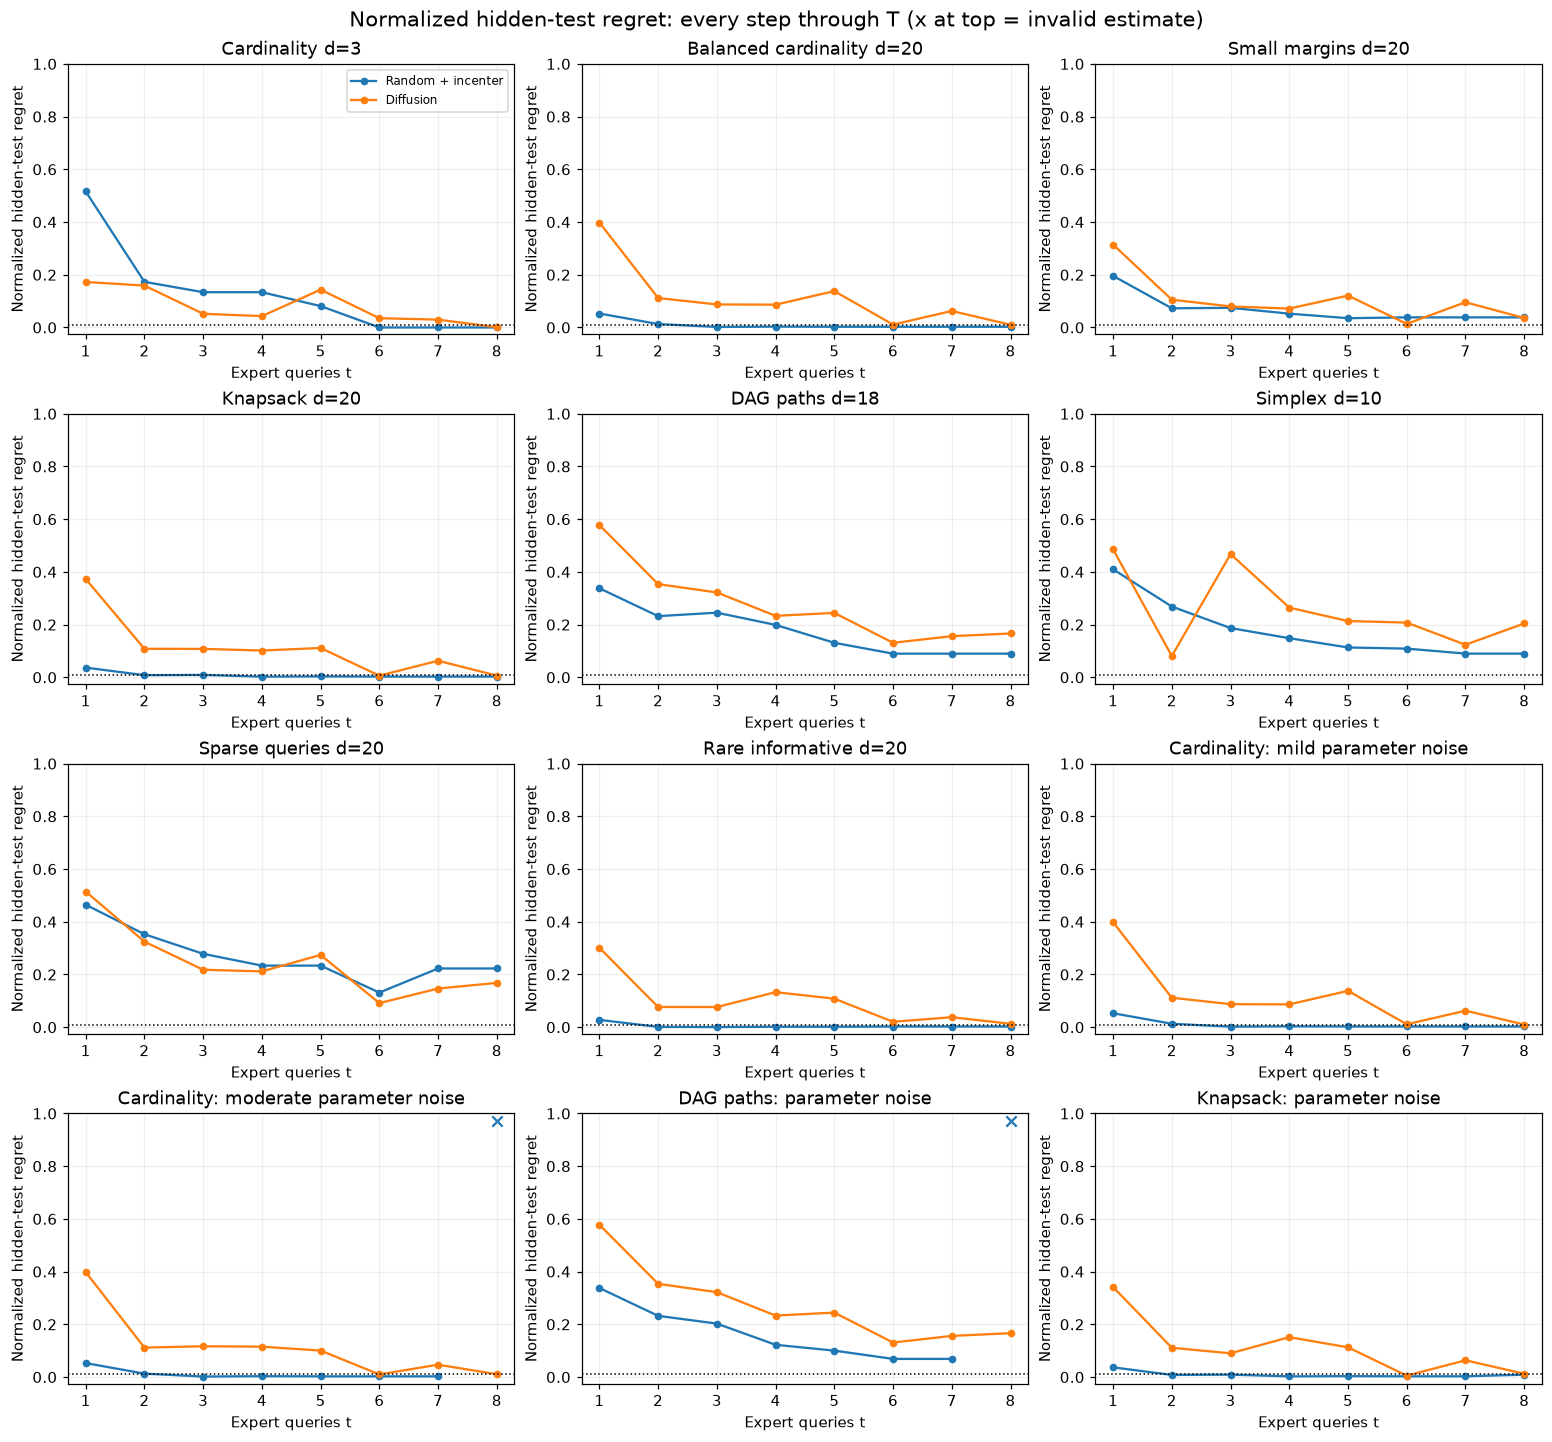

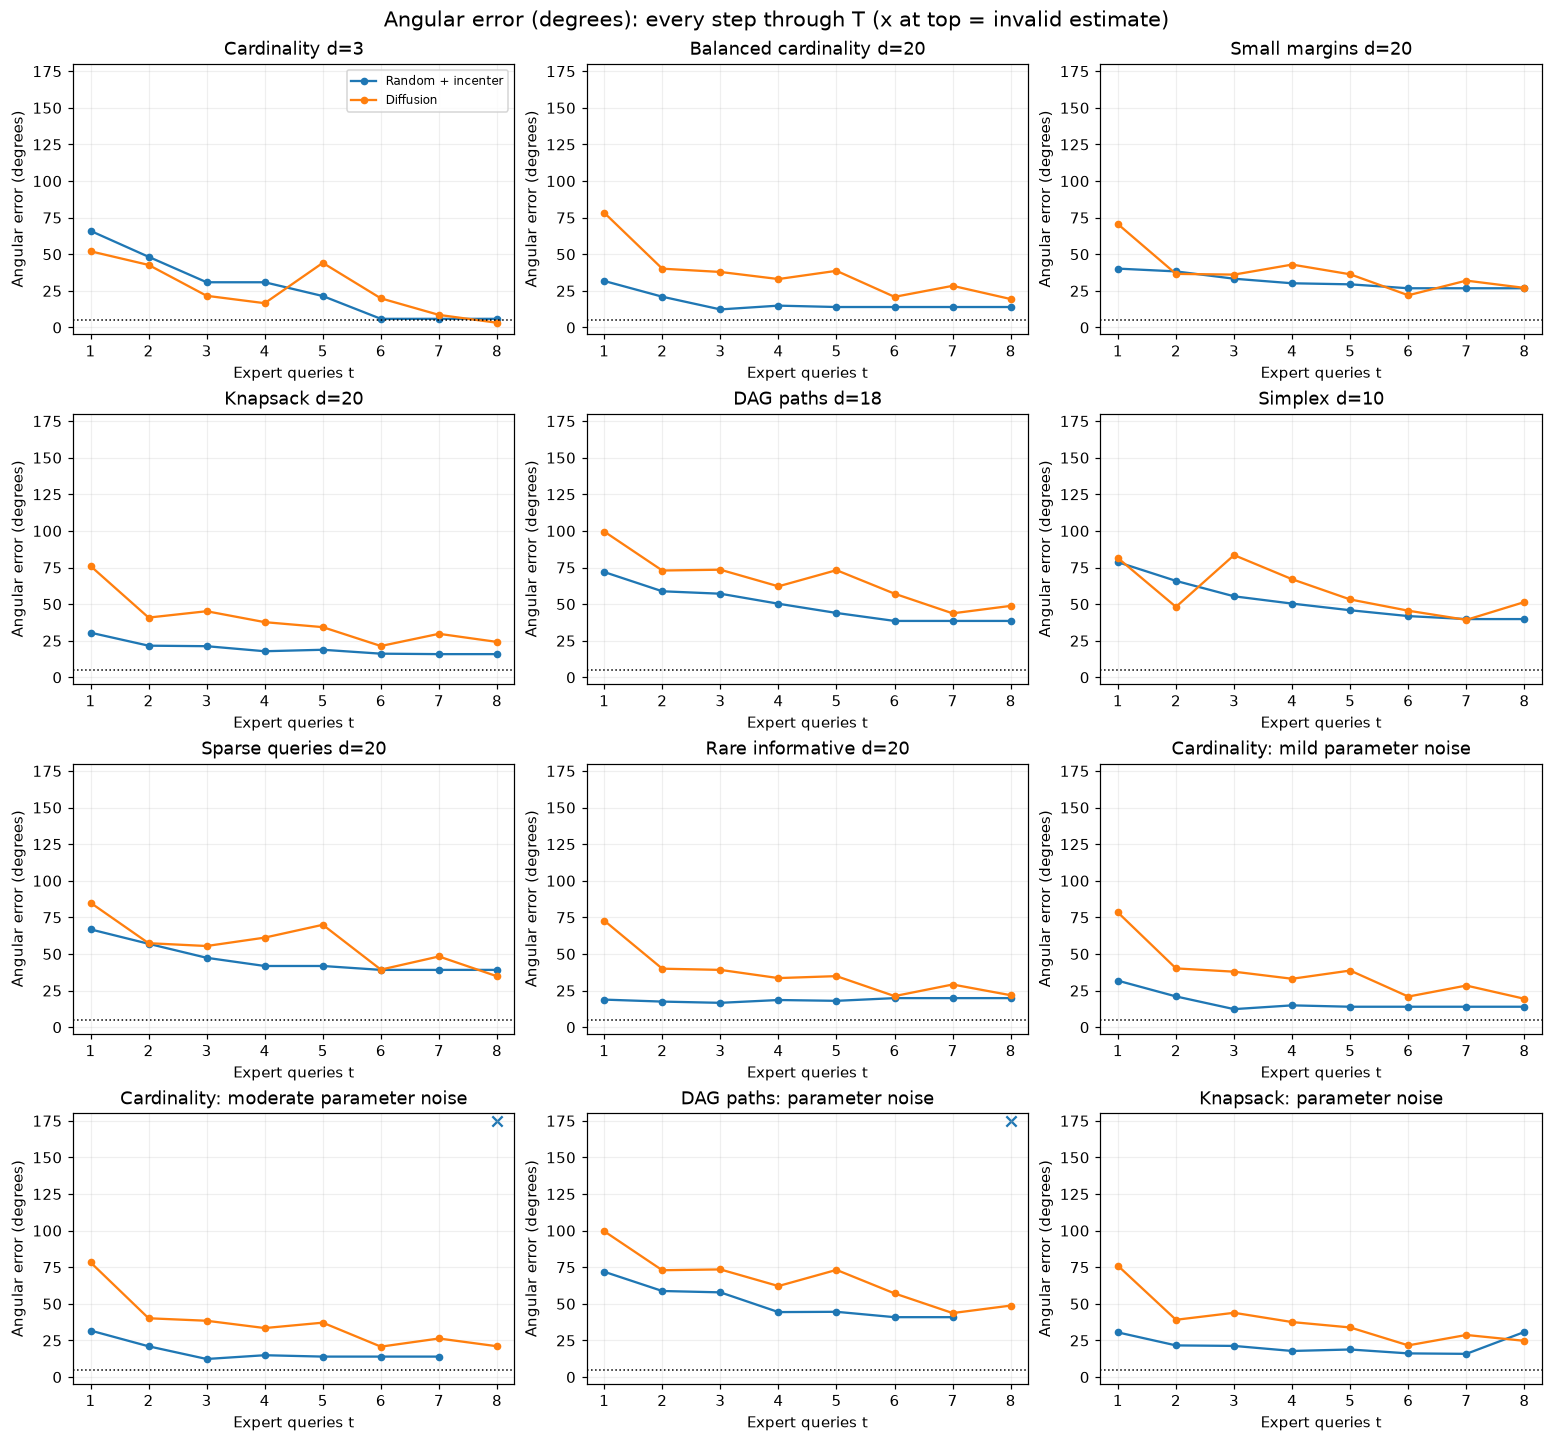

In [6]:
colors = {"Random + incenter": "tab:blue", "Diffusion": "tab:orange"}
families = scenario_table.family.tolist()
short_titles = {
    "geometry-cardinality-3d": "Cardinality d=3",
    "cardinality-balanced-d20": "Balanced cardinality d=20",
    "cardinality-small-margin-d20": "Small margins d=20",
    "knapsack-d20": "Knapsack d=20",
    "dag-path-d18": "DAG paths d=18",
    "continuous-simplex-d10": "Simplex d=10",
    "cardinality-sparse-queries-d20": "Sparse queries d=20",
    "cardinality-rare-informative-d20": "Rare informative d=20",
    "cardinality-parameter-noise-mild-d20": "Cardinality: mild parameter noise",
    "cardinality-parameter-noise-moderate-d20": "Cardinality: moderate parameter noise",
    "dag-path-parameter-noise-moderate-d18": "DAG paths: parameter noise",
    "knapsack-parameter-noise-moderate-d20": "Knapsack: parameter noise",
}

def trajectory_grid(column, label, threshold, ymax):
    fig, axes = plt.subplots(4, 3, figsize=(14, 13), constrained_layout=True)
    for ax, family in zip(axes.flat, families):
        for name, color in colors.items():
            data = trajectory[(trajectory.family == family) & (trajectory.algorithm == name)]
            ax.plot(data.t, data[column], "o-", label=name, color=color, markersize=4)
            failed = data[~data.valid]
            if len(failed):
                ax.scatter(failed.t, [ymax * .97] * len(failed), marker="x", s=45, color=color)
        if threshold is not None:
            ax.axhline(threshold, color="black", ls=":", lw=1)
        ax.set(title=short_titles[family], xlabel="Expert queries t", ylabel=label,
               xlim=(0.7, protocol.horizon + 0.3), ylim=(-0.025 * ymax, ymax))
        ax.set_xticks(range(1, protocol.horizon + 1))
        ax.grid(alpha=.2)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(f"{label}: every step through T (x at top = invalid estimate)", fontsize=14)
    plt.show()

trajectory_grid("regret", "Normalized hidden-test regret", protocol.learning_regret_threshold, 1.0)
trajectory_grid("angle_deg", "Angular error (degrees)", protocol.learning_angular_threshold_degrees, 180.0)


## Detailed noisy trajectories and failures

A cross at the top of a panel indicates an invalid estimate; it is NOT a regret or angular-error value. Gaps are intentional. A high but finite angle from a valid Diffusion sample remains a real error and is not hidden. Sample norms are shown because small magnitudes can occur under inconsistent noisy demonstrations.


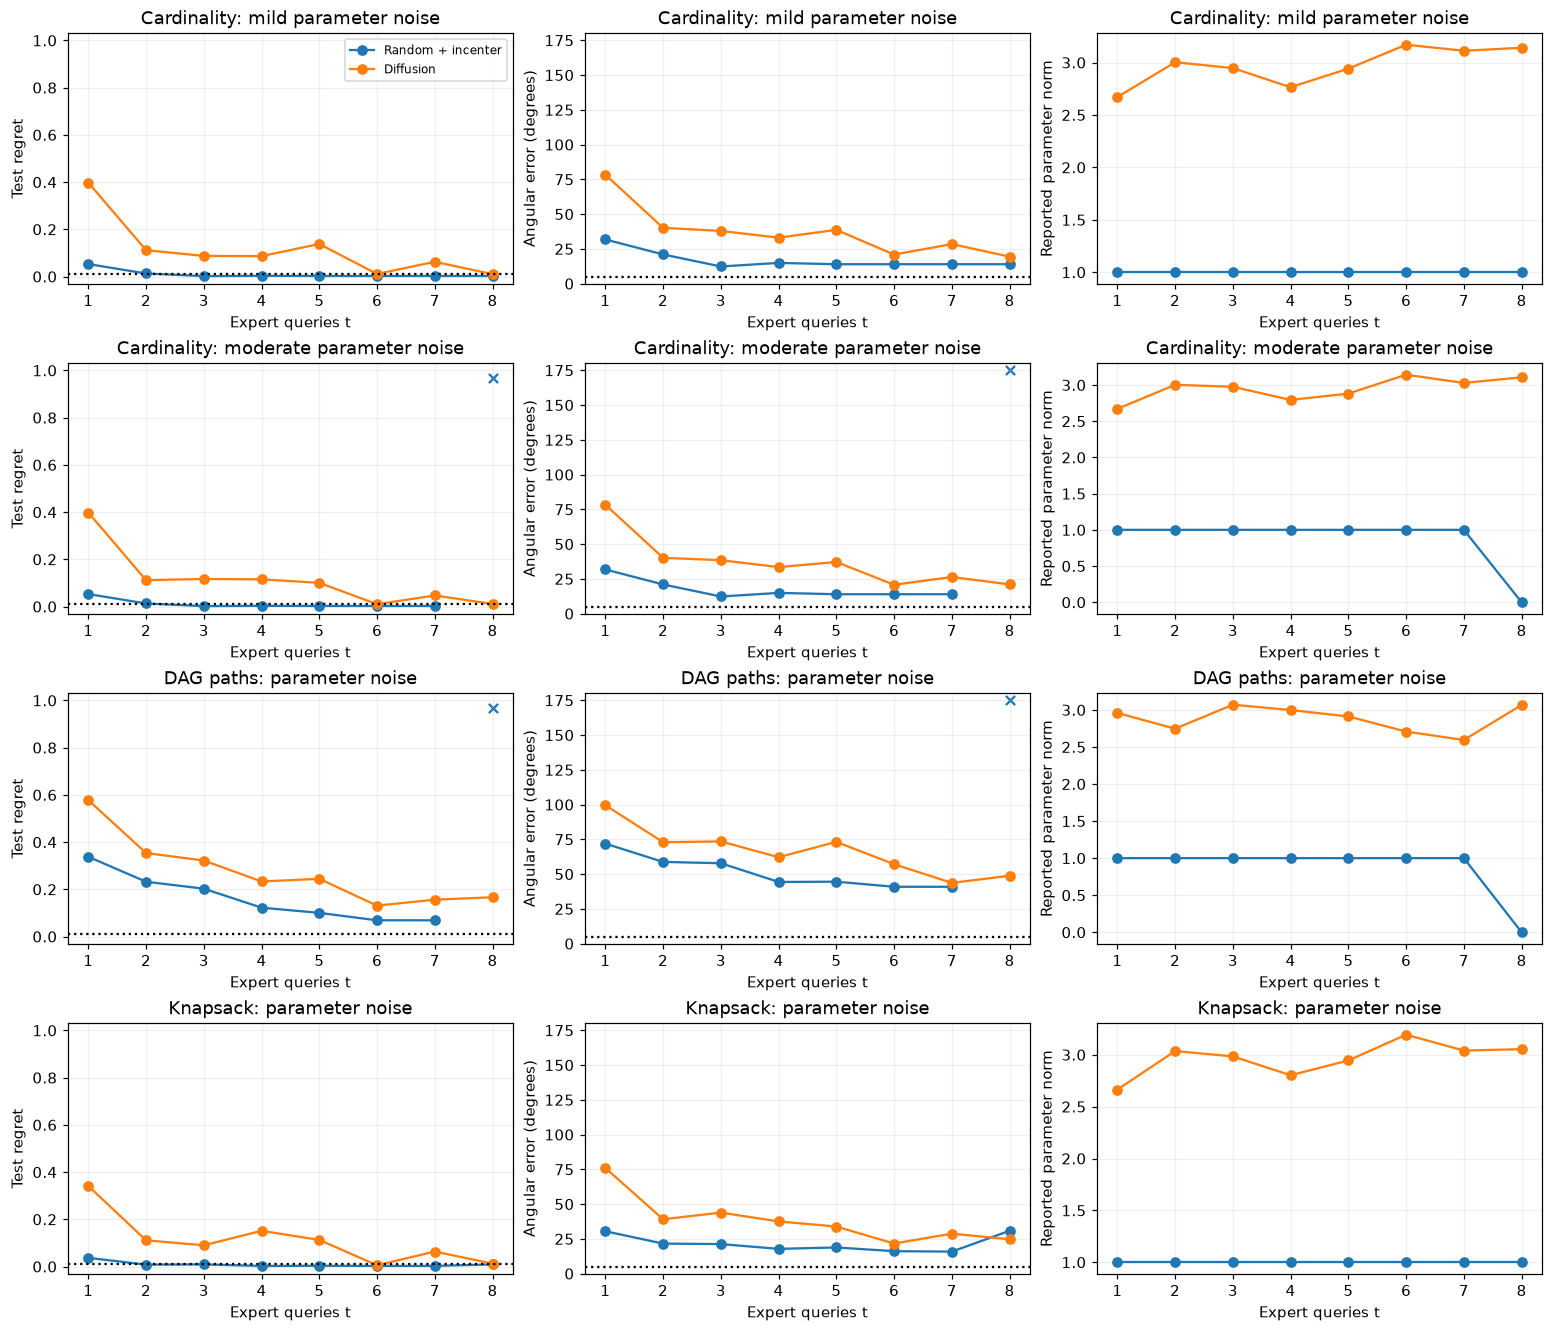

,family,algorithm,noise,t,theta_norm,regret,angle_deg,zero_regret_fraction,valid,status
128,cardinality-parameter-noise-mild-d20,Random + incenter,True,1,1.00000,0.05294,31.76078,0.09375,True,valid
129,cardinality-parameter-noise-mild-d20,Random + incenter,True,2,1.00000,0.01294,21.00173,0.43750,True,valid
130,cardinality-parameter-noise-mild-d20,Random + incenter,True,3,1.00000,0.00196,12.33017,0.65625,True,valid
131,cardinality-parameter-noise-mild-d20,Random + incenter,True,4,1.00000,0.00322,14.90473,0.62500,True,valid
132,cardinality-parameter-noise-mild-d20,Random + incenter,True,5,1.00000,0.00264,13.96455,0.62500,True,valid
133,cardinality-parameter-noise-mild-d20,Random + incenter,True,6,1.00000,0.00264,13.96455,0.62500,True,valid
134,cardinality-parameter-noise-mild-d20,Random + incenter,True,7,1.00000,0.00264,13.96455,0.62500,True,valid
135,cardinality-parameter-noise-mild-d20,Random + incenter,True,8,1.00000,0.00264,13.96455,0.62500,True,valid
136,cardinality-parameter-noise-mild-d20,Diffusion,True,1,2.67053,0.39816,78.35268,0.00000,True,valid
137,cardinality-parameter-noise-mild-d20,Diffusion,True,2,3.00301,0.11172,40.14647,0.03125,True,valid


In [7]:
noisy_families = scenario_table.loc[scenario_table.parameter_noise != "none", "family"].tolist()
fig, axes = plt.subplots(4, 3, figsize=(14, 12), constrained_layout=True)
for row, family in enumerate(noisy_families):
    for name, color in colors.items():
        data = trajectory[(trajectory.family == family) & (trajectory.algorithm == name)]
        axes[row, 0].plot(data.t, data.regret, "o-", color=color, label=name)
        axes[row, 1].plot(data.t, data.angle_deg, "o-", color=color, label=name)
        axes[row, 2].plot(data.t, data.theta_norm, "o-", color=color, label=name)
        for col, height in ((0, .97), (1, 175)):
            bad = data[~data.valid]
            axes[row, col].scatter(bad.t, [height] * len(bad), marker="x", color=color)
    axes[row, 0].axhline(.01, ls=":", color="black")
    axes[row, 1].axhline(5, ls=":", color="black")
    for col, label in enumerate(["Test regret", "Angular error (degrees)", "Reported parameter norm"]):
        axes[row, col].set(title=short_titles[family], xlabel="Expert queries t", ylabel=label)
        axes[row, col].set_xticks(range(1, 9))
        axes[row, col].grid(alpha=.2)
    axes[row, 0].set_ylim(-.03, 1.03)
    axes[row, 1].set_ylim(0, 180)
axes[0, 0].legend(fontsize=8)
plt.show()
display(trajectory[trajectory.noise].round(5))


## Which reached a useful estimate sooner?

Compare first-hit times separately from sustained-through-T times. A missing time means “not reached by T”, not “took exactly T”. The joint threshold requires both an accurate direction and low regret. The figures show observed threshold times as points; x markers to the right mean not reached.


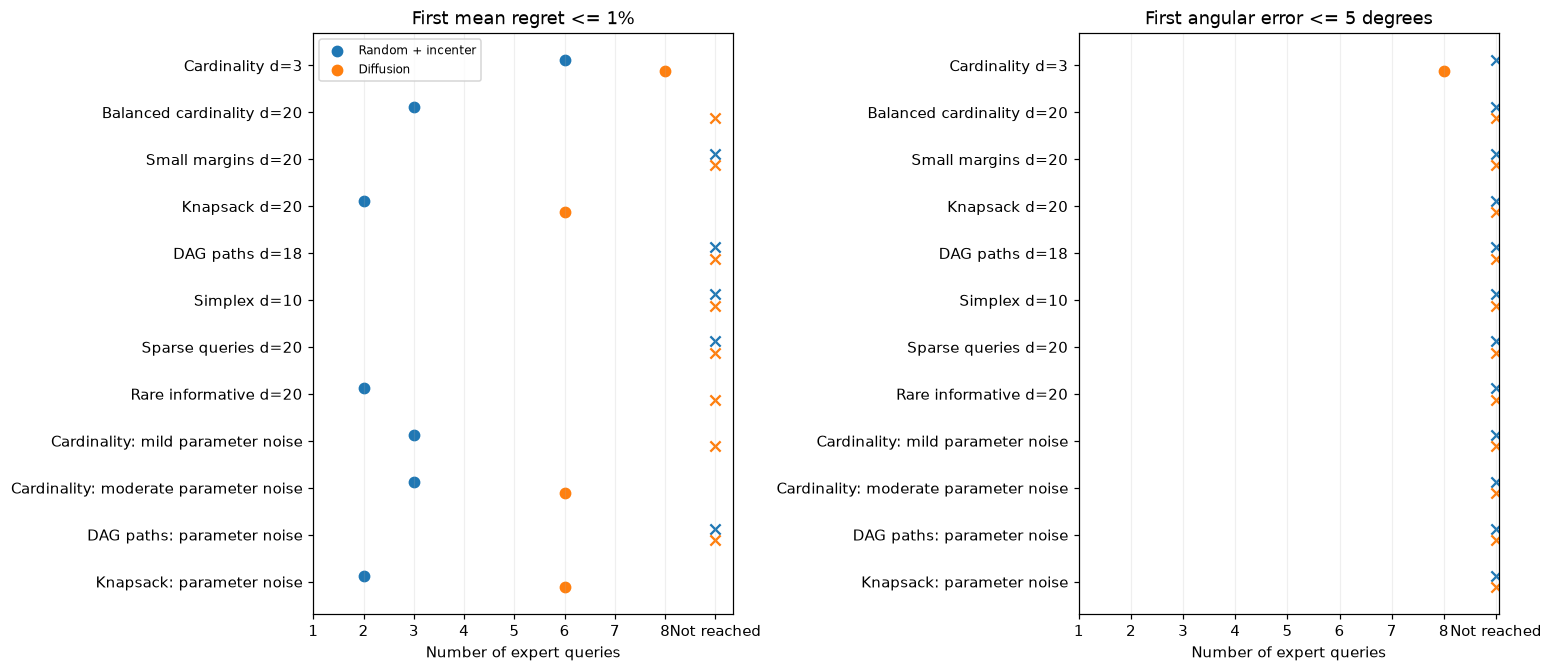

,family,first_angle,first_regret,stable_both,valid_final_pair,lower_final_regret
0,geometry-cardinality-3d,Diffusion only,Random earlier,Diffusion only,True,Random
1,cardinality-balanced-d20,Neither reached,Random only,Neither reached,True,Random
2,cardinality-small-margin-d20,Neither reached,Neither reached,Neither reached,True,Diffusion
3,knapsack-d20,Neither reached,Random earlier,Neither reached,True,Random
4,dag-path-d18,Neither reached,Neither reached,Neither reached,True,Random
5,continuous-simplex-d10,Neither reached,Neither reached,Neither reached,True,Random
6,cardinality-sparse-queries-d20,Neither reached,Neither reached,Neither reached,True,Diffusion
7,cardinality-rare-informative-d20,Neither reached,Random only,Neither reached,True,Random
8,cardinality-parameter-noise-mild-d20,Neither reached,Random only,Neither reached,True,Random
9,cardinality-parameter-noise-moderate-d20,Neither reached,Random earlier,Neither reached,False,Not comparable: failure


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, column, title in zip(
    axes, ["first_regret_t", "first_angle_t"],
    ["First mean regret <= 1%", "First angular error <= 5 degrees"],
):
    for offset, (name, color) in zip([-.12, .12], colors.items()):
        data = results[results.algorithm == name].set_index("family").reindex(families)
        times = data[column].to_numpy(dtype=float)
        y = np.arange(len(families)) + offset
        valid = np.isfinite(times)
        ax.scatter(times[valid], y[valid], color=color, label=name, s=45)
        ax.scatter(np.full((~valid).sum(), protocol.horizon+1), y[~valid], color=color, marker="x", s=45)
    ax.set_yticks(range(len(families)), [short_titles[f] for f in families])
    ax.invert_yaxis()
    ax.set_xticks(range(1, 10), [str(t) for t in range(1, 9)] + ["Not reached"])
    ax.set(title=title, xlabel="Number of expert queries")
    ax.grid(axis="x", alpha=.2)
axes[0].legend(fontsize=8)
plt.show()

comparison_rows = []
for family in families:
    pair = results[results.family == family].set_index("algorithm")
    a, b = pair.loc["Random + incenter"], pair.loc["Diffusion"]
    def compare_time(column):
        x, y = a[column], b[column]
        if pd.isna(x) and pd.isna(y): return "Neither reached"
        if pd.isna(x): return "Diffusion only"
        if pd.isna(y): return "Random only"
        return "Same step" if x == y else "Random earlier" if x < y else "Diffusion earlier"
    both_valid = a.status == "valid" and b.status == "valid"
    comparison_rows.append({
        "family": family, "first_angle": compare_time("first_angle_t"),
        "first_regret": compare_time("first_regret_t"),
        "stable_both": compare_time("stable_both_t"),
        "valid_final_pair": both_valid,
        "lower_final_regret": ("Not comparable: failure" if not both_valid else
            "Tie" if np.isclose(a.final_regret, b.final_regret, atol=1e-12, rtol=0) else
            "Random" if a.final_regret < b.final_regret else "Diffusion"),
    })
comparison = pd.DataFrame(comparison_rows)
display(comparison)


## Computational time and integrity checks

These are equal QUERY budgets, not equal computation budgets. Diffusion performs many forward solves per query and may take longer in seconds even when it needs fewer observations. Runtimes include algorithm initialization; environment setup, calibration and final hidden evaluation are outside individual algorithm-run runtime. The overall notebook wall time includes those additional costs.


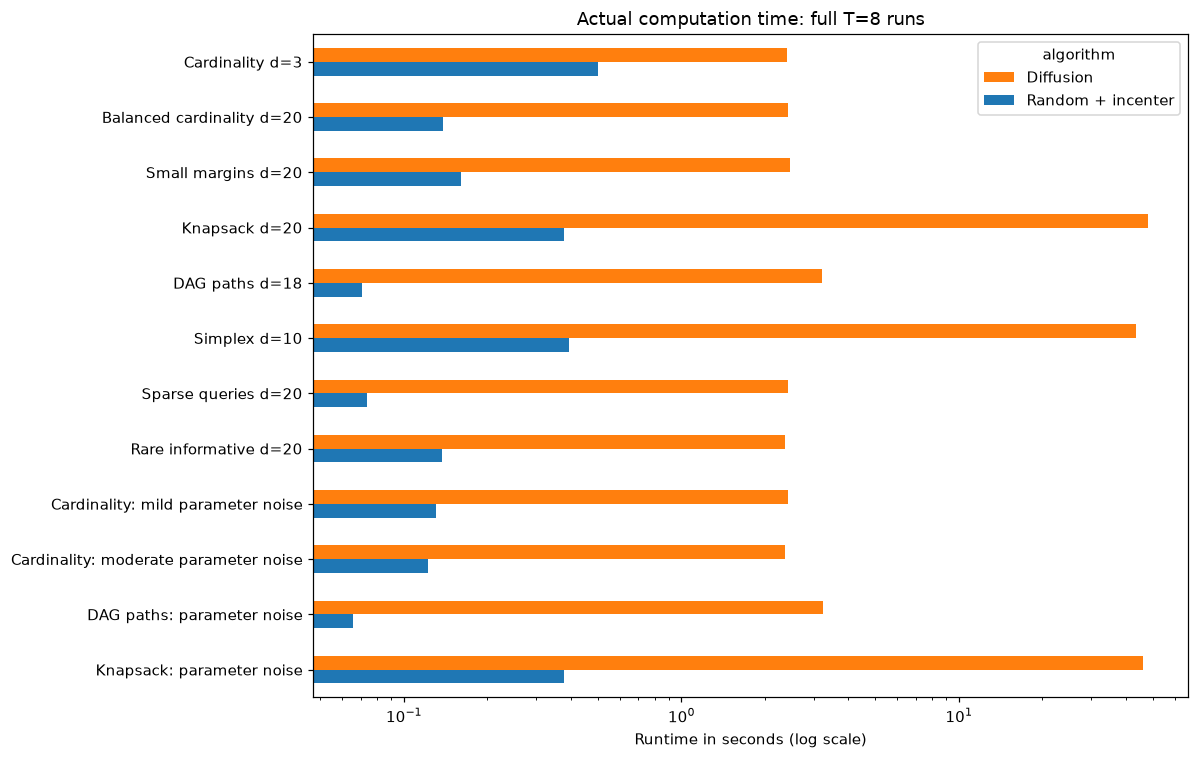

All 24 runs completed the full horizon. Noise, query-rule and estimate-rule checks passed.
Overall comparison wall time: 171.14 seconds.
No aggregate superiority claim: one seed and a small diffusion sampling budget.


In [9]:
runtime = results.pivot(index="family", columns="algorithm", values="runtime_seconds").reindex(families)
ax = runtime.plot.barh(figsize=(11, 7), color=[colors[c] for c in runtime.columns], logx=True)
ax.set_yticklabels([short_titles[f] for f in families])
ax.set(xlabel="Runtime in seconds (log scale)", ylabel="", title="Actual computation time: full T=8 runs")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

assert len(benchmark.runs) == 24
assert not benchmark.failed_runs, "An execution failure must be inspected before interpreting the comparison."
assert all(len(r.records) == protocol.horizon for r in benchmark.runs)
assert all(not r.metadata["external_stopping_enabled"] and not r.stopped_early for r in benchmark.runs)
for run in benchmark.runs:
    assert run.evaluation["metadata"]["test_queries_hidden_from_algorithm"]
    assert all(np.array_equal(r.true_decision, r.observed_decision) for r in run.records)
    if run.algorithm_name == "Diffusion":
        for record in run.records:
            d = record.update_diagnostics
            np.testing.assert_array_equal(record.theta_hat_after, d["theta_samples"][0])
            assert record.action_diagnostics["selected_score"] == max(record.action_diagnostics["candidate_scores"])
    else:
        assert all(r.action_diagnostics["query_rule"] == "uniform-random" for r in run.records)
print("All 24 runs completed the full horizon. Noise, query-rule and estimate-rule checks passed.")
print("Overall comparison wall time:", round(wall_seconds, 2), "seconds.")
print("No aggregate superiority claim: one seed and a small diffusion sampling budget.")


## Findings from this saved run (seed 0, T=8)

All 24 executions reached T=8. There were no execution errors. Random + incenter had two invalid final estimates (collapsed cones); Diffusion returned valid nonzero estimates in all 12 cases. Valid does not mean accurate.

**In the four parameter-noise cases, neither algorithm ever reached 5 degrees angular error.** For the 1% mean-regret threshold:

| Parameter-noise scenario | Random first t | Diffusion first t | Random sustained through T | Diffusion sustained through T |
|---|---:|---:|---:|---:|
| Cardinality, mild | 3 | Not reached | 3 | Not reached |
| Cardinality, moderate | 3 | 6 | Not reached (later failed) | Not reached |
| DAG paths, moderate | Not reached | Not reached | Not reached (failed) | Not reached |
| Knapsack, moderate | 2 | 6 | 2 | Not reached |

Thus this small-budget run does **not** show faster learning from Diffusion in the noisy cases. In the clean 3D case, Diffusion reached 5 degrees at t=8; Random did not, although Random reached low regret sooner there.

### Realized parameter-noise audit

After the experiment, using the saved latent records ONLY for evaluation, each expert decision was compared with the clean MIN decision under theta* at the SAME queried S. The counts below are decisions changed by parameter noise out of eight interactions; each changed decision also had strictly positive clean objective regret in this run.

| Parameter-noise scenario | Random changed decisions / 8 | Diffusion changed decisions / 8 |
|---|---:|---:|
| Cardinality, mild | 0 | 0 |
| Cardinality, moderate | 1 | 3 |
| DAG paths, moderate | 2 | 0 |
| Knapsack, moderate | 1 | 2 |

Parameter perturbations were enabled throughout all four scenarios, but some short trajectories experienced no decision changes. In particular, Diffusion's lack of failure in the noisy path case is NOT by itself evidence of robustness to corrupted decisions: its selected queries experienced no decision changes here. Moderate cardinality and knapsack did produce changed decisions for both algorithms.

These are fixed, post-run notes for the saved outputs. If you edit the inputs and rerun the notebook, regenerate this interpretation and audit rather than treating these numbers as new results.

## How to interpret and extend this comparison

The complete tables above are the results, including unfavorable outcomes. Do not treat a single small-budget run as proof that either method is better. Reaching low regret can precede parameter recovery; some scenarios do not identify all parameter directions well. The raw angular curves are therefore as important as threshold times.

Parameter noise creates inconsistent hard constraints, so the incenter method can explicitly fail. Diffusion avoids requiring a hard consistency cone, but that alone does not guarantee accurate estimates: finite-chain mixing, a small ensemble, the first-sample estimator, beta, step sizes, and magnitude concentration all matter.

For a stronger study later, predefine a larger T and multiple seeds, check sampler convergence/step-size sensitivity, and use adequate held-out query counts. To isolate query selection itself, compare the SAME estimator under random versus disagreement-based queries. Those are future experiments, not hidden extra runs in this notebook.
